<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/Linear_Regression_CS23149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze electricity consumption data from "/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv" by performing data preprocessing, feature engineering, and training a Linear Regression model for electricity load forecasting. Evaluate the model's performance using 80:20 and 70:30 train-test splits, comparing metrics (MAE, MSE, R-squared) and visualizing actual vs. predicted values for each split, and provide a comprehensive summary of the findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset



In [2]:
df = pd.read_csv('/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv')
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


## Data Information and Overview



In [3]:
print("\n--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
df.describe()

print("\n--- Missing Values ---")
df.isnull().sum()


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

--- Descriptive Statistics ---

--- Missing Values ---


,0
Circle,0
Division,0
SubDivision,0
Section,0
Area,0
CatCode,0
CatDesc,0
TotServices,0
BilledServices,0
Units,0


## Data Preprocessing

### Subtask:
Perform necessary data cleaning and preprocessing steps. This may include handling missing values, converting data types, or extracting relevant features from existing columns.


**Reasoning**:
I will examine the unique values and their counts for all 'object' type columns and the 'CatCode' column to understand their cardinality and distribution, which will aid in identifying columns suitable for encoding or dropping.



In [4]:
categorical_cols = ['Circle', 'Division', 'SubDivision', 'Section', 'Area', 'CatDesc', 'CatCode']

for col in categorical_cols:
    print(f"\n--- Value counts for {col} ---")
    print(df[col].value_counts())



--- Value counts for Circle ---
Circle
BHADRADRI KOTHAGUDEM    782
KHAMMAM                 773
NIZAMABAD               610
ADILABAD                590
MAHABUBABAD             567
BHUPALAPALLY            549
KAMAREDDY               520
KARIMNAGAR              507
MANCHERIAL              500
NIRMAL                  495
ASIFABAD                484
WARANGAL                474
HANUMAKONDA             424
JAGITYAL                404
PEDDAPALLY              348
JANGAON                 308
Name: count, dtype: int64

--- Value counts for Division ---
Division
ADILABAD             386
MAHABUBABAD          362
MANCHERIAL           345
KOTHAGUDEM           327
BHUPALAPALLY         288
NIRMAL               281
JAGITYAL             277
HANAMKONDA/RURAL     271
ASIFABAD             264
BHADRACHALAM         261
MULUGU               261
KHAMMAM              251
SIRPUR KAGAZNAGAR    220
BHAINSA              214
NARSAMPET            210
BANSWADA             209
SATHUPALLY           205
THORRUR          

**Reasoning**:
Based on the value counts, 'CatDesc' and 'CatCode' columns contain only one unique value, making them redundant. The 'Area' column has very high cardinality (7224 unique values), making it impractical for direct encoding and likely irrelevant for a generalized model, so it will be dropped. The remaining categorical columns ('Circle', 'Division', 'SubDivision', 'Section') will be considered for encoding.



In [5]:
df = df.drop(columns=['CatDesc', 'CatCode', 'Area'])
print("Dropped 'CatDesc', 'CatCode', and 'Area' columns.")
print(df.head())

Dropped 'CatDesc', 'CatCode', and 'Area' columns.
     Circle        Division   SubDivision       Section  TotServices  \
0  WARANGAL  RURAL WARANGAL  WARDHANNAPET       MYLARAM            5   
1  WARANGAL        WARANGAL      WARANGAL  STATION ROAD          392   
2  WARANGAL        WARANGAL      WARANGAL  STATION ROAD          492   
3  WARANGAL        WARANGAL      WARANGAL  STATION ROAD          458   
4  WARANGAL        WARANGAL      WARANGAL  STATION ROAD          326   

   BilledServices   Units      Load  
0               5      84    11.000  
1             334   44762   872.100  
2             431   31931   568.730  
3             407   28871   657.578  
4             262  111598  2199.410  


In [6]:
categorical_cols_to_encode = ['Circle', 'Division', 'SubDivision', 'Section']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)
print("Categorical columns one-hot encoded.")
print(f"New DataFrame shape: {df.shape}")
print(df.head())

Categorical columns one-hot encoded.
New DataFrame shape: (8335, 633)
   TotServices  BilledServices   Units      Load  Circle_ASIFABAD  \
0            5               5      84    11.000            False   
1          392             334   44762   872.100            False   
2          492             431   31931   568.730            False   
3          458             407   28871   657.578            False   
4          326             262  111598  2199.410            False   

   Circle_BHADRADRI KOTHAGUDEM  Circle_BHUPALAPALLY  Circle_HANUMAKONDA  \
0                        False                False               False   
1                        False                False               False   
2                        False                False               False   
3                        False                False               False   
4                        False                False               False   

   Circle_JAGITYAL  Circle_JANGAON  ...  Section_YEDPALLY  \
0  

In [7]:
numerical_cols_to_scale = ['TotServices', 'BilledServices', 'Units']

print("Numerical columns identified for scaling:")
print(numerical_cols_to_scale)

Numerical columns identified for scaling:
['TotServices', 'BilledServices', 'Units']


In [8]:
scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical columns scaled successfully.")
print(df.head())

Numerical columns scaled successfully.
   TotServices  BilledServices     Units      Load  Circle_ASIFABAD  \
0    -0.283900       -0.284638 -0.271360    11.000            False   
1     1.364661        1.339192  1.066856   872.100            False   
2     1.790646        1.817951  0.682536   568.730            False   
3     1.645811        1.699495  0.590881   657.578            False   
4     1.083511        0.983825  3.068758  2199.410            False   

   Circle_BHADRADRI KOTHAGUDEM  Circle_BHUPALAPALLY  Circle_HANUMAKONDA  \
0                        False                False               False   
1                        False                False               False   
2                        False                False               False   
3                        False                False               False   
4                        False                False               False   

   Circle_JAGITYAL  Circle_JANGAON  ...  Section_YEDPALLY  \
0            False    

## Define Features and Target




In [9]:
y = df['Load']
X = df.drop('Load', axis=1)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (8335, 632)
Shape of y: (8335,)


## Train-Test Split (80:20)

In [22]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train (80:20 split): {X_train_80.shape}")
print(f"Shape of X_test (80:20 split): {X_test_80.shape}")
print(f"Shape of y_train (80:20 split): {y_train_80.shape}")
print(f"Shape of y_test (80:20 split): {y_test_80.shape}")

Shape of X_train (80:20 split): (6668, 632)
Shape of X_test (80:20 split): (1667, 632)
Shape of y_train (80:20 split): (6668,)
Shape of y_test (80:20 split): (1667,)


### Scaling numerical features for 80:20 split

In [23]:
scaler_80 = StandardScaler()
X_train_80[numerical_cols_to_scale] = scaler_80.fit_transform(X_train_80[numerical_cols_to_scale])
X_test_80[numerical_cols_to_scale] = scaler_80.transform(X_test_80[numerical_cols_to_scale])

print("Numerical columns scaled for 80:20 split successfully.")
print("X_train_80 head after scaling:")
display(X_train_80.head())
print("X_test_80 head after scaling:")
display(X_test_80.head())

Numerical columns scaled for 80:20 split successfully.
X_train_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
2233,5.161918,5.456363,3.815199,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6798,-0.172597,-0.166034,-0.172618,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3964,-0.006955,-0.002707,-0.008894,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1321,-0.159855,-0.141287,-0.201538,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8140,-0.295766,-0.304614,-0.260752,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


X_test_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
1768,-0.257541,-0.265019,-0.239171,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5550,-0.266036,-0.269969,-0.244230,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7978,-0.295766,-0.299665,-0.267887,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
932,-0.270283,-0.269969,-0.265138,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5357,-0.244800,-0.250172,-0.183993,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Train Linear Regression Model (80:20 Split)

In [24]:
model_80 = LinearRegression()
model_80.fit(X_train_80, y_train_80)

print("Linear Regression model trained successfully for 80:20 split.")

Linear Regression model trained successfully for 80:20 split.


### Make Predictions (80:20 Split)

In [25]:
y_pred_80 = model_80.predict(X_test_80)

print("Predictions made successfully for 80:20 split.")
print(f"First 5 predictions: {y_pred_80[:5]}")
print(f"First 5 actual values: {y_test_80[:5].values}")

Predictions made successfully for 80:20 split.
First 5 predictions: [ 9.40193298  9.17700358  3.39707138 -0.50349813 23.92708459]
First 5 actual values: [21.2   24.728  2.    11.    32.36 ]


### Evaluate Model Performance (80:20 Split)

In [26]:
mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

print(f"--- Performance Metrics (80:20 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_80:.2f}")
print(f"Mean Squared Error (MSE): {mse_80:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_80:.2f}")
print(f"R-squared (R2): {r2_80:.2f}")

--- Performance Metrics (80:20 Split) ---
Mean Absolute Error (MAE): 33.61
Mean Squared Error (MSE): 5764.84
Root Mean Squared Error (RMSE): 75.93
R-squared (R2): 0.98


### Visualize Actual vs. Predicted (80:20 Split)

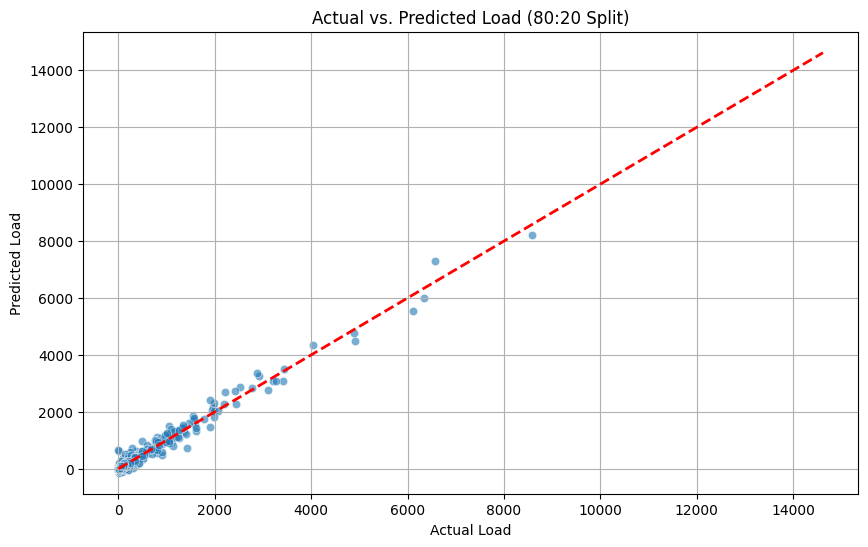

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_80, y=y_pred_80, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (80:20 Split)')
plt.grid(True)
plt.show()

In [28]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train (80:20 split): {X_train_80.shape}")
print(f"Shape of X_test (80:20 split): {X_test_80.shape}")
print(f"Shape of y_train (80:20 split): {y_train_80.shape}")
print(f"Shape of y_test (80:20 split): {y_test_80.shape}")

Shape of X_train (80:20 split): (6668, 632)
Shape of X_test (80:20 split): (1667, 632)
Shape of y_train (80:20 split): (6668,)
Shape of y_test (80:20 split): (1667,)


In [29]:
scaler_80 = StandardScaler()
X_train_80[numerical_cols_to_scale] = scaler_80.fit_transform(X_train_80[numerical_cols_to_scale])
X_test_80[numerical_cols_to_scale] = scaler_80.transform(X_test_80[numerical_cols_to_scale])

print("Numerical columns scaled for 80:20 split successfully.")
print("X_train_80 head after scaling:")
display(X_train_80.head())
print("X_test_80 head after scaling:")
display(X_test_80.head())

Numerical columns scaled for 80:20 split successfully.
X_train_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
2233,5.161918,5.456363,3.815199,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6798,-0.172597,-0.166034,-0.172618,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3964,-0.006955,-0.002707,-0.008894,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1321,-0.159855,-0.141287,-0.201538,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8140,-0.295766,-0.304614,-0.260752,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


X_test_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
1768,-0.257541,-0.265019,-0.239171,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5550,-0.266036,-0.269969,-0.244230,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7978,-0.295766,-0.299665,-0.267887,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
932,-0.270283,-0.269969,-0.265138,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5357,-0.244800,-0.250172,-0.183993,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [30]:
model_80 = LinearRegression()
model_80.fit(X_train_80, y_train_80)

print("Linear Regression model trained successfully for 80:20 split.")

Linear Regression model trained successfully for 80:20 split.


In [31]:
y_pred_80 = model_80.predict(X_test_80)

print("Predictions made successfully for 80:20 split.")
print(f"First 5 predictions: {y_pred_80[:5]}")
print(f"First 5 actual values: {y_test_80[:5].values}")

Predictions made successfully for 80:20 split.
First 5 predictions: [ 9.40193298  9.17700358  3.39707138 -0.50349813 23.92708459]
First 5 actual values: [21.2   24.728  2.    11.    32.36 ]


In [32]:
mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

print(f"--- Performance Metrics (80:20 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_80:.2f}")
print(f"Mean Squared Error (MSE): {mse_80:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_80:.2f}")
print(f"R-squared (R2): {r2_80:.2f}")

--- Performance Metrics (80:20 Split) ---
Mean Absolute Error (MAE): 33.61
Mean Squared Error (MSE): 5764.84
Root Mean Squared Error (RMSE): 75.93
R-squared (R2): 0.98


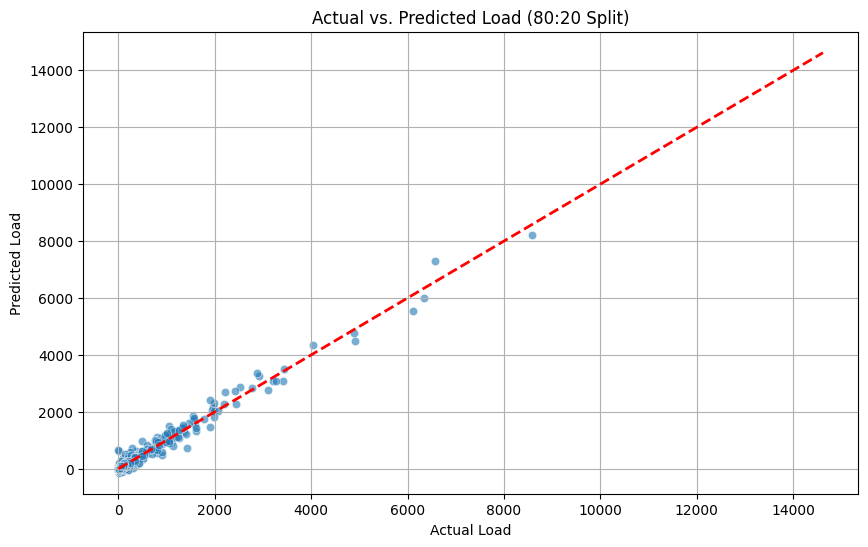

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_80, y=y_pred_80, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (80:20 Split)')
plt.grid(True)
plt.show()

## Compare Model Performance for Both Splits

   Split    MAE      MSE   RMSE  R-squared
0  70:30  34.68  5927.43  76.99       0.98
1  80:20  33.61  5764.84  75.93       0.98

--- Visual Comparison of R-squared ---


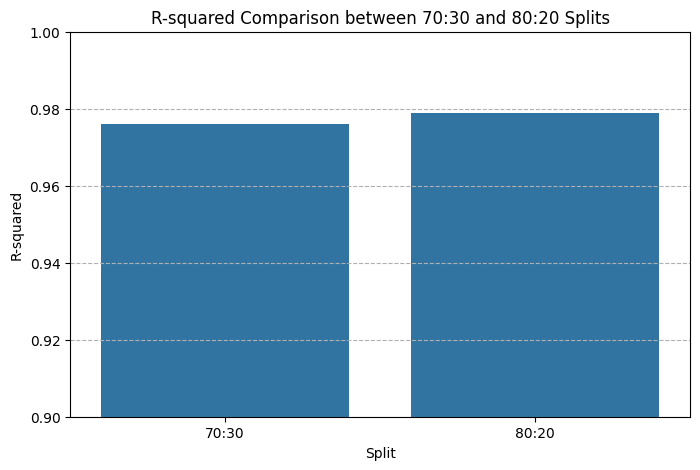


--- Visual Comparison of MAE ---


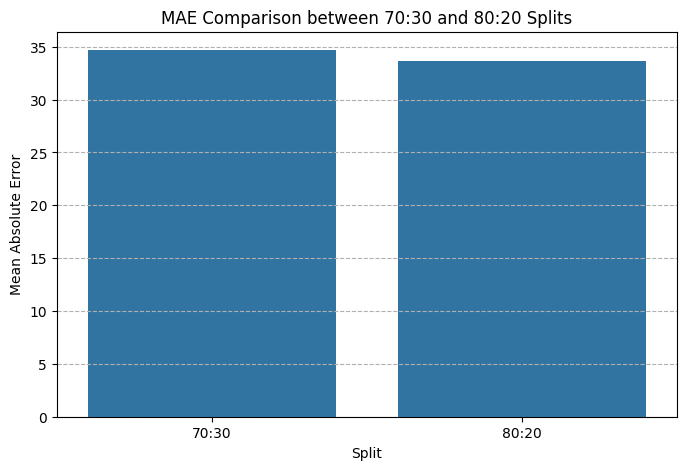

In [34]:
metrics_data = {
    'Split': ['70:30', '80:20'],
    'MAE': [mae_70, mae_80],
    'MSE': [mse_70, mse_80],
    'RMSE': [rmse_70, rmse_80],
    'R-squared': [r2_70, r2_80]
}

performance_df = pd.DataFrame(metrics_data)
print(performance_df.round(2))

print("\n--- Visual Comparison of R-squared ---")
plt.figure(figsize=(8, 5))
sns.barplot(x='Split', y='R-squared', data=performance_df)
plt.title('R-squared Comparison between 70:30 and 80:20 Splits')
plt.ylabel('R-squared')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()

print("\n--- Visual Comparison of MAE ---")
plt.figure(figsize=(8, 5))
sns.barplot(x='Split', y='MAE', data=performance_df)
plt.title('MAE Comparison between 70:30 and 80:20 Splits')
plt.ylabel('Mean Absolute Error')
plt.grid(axis='y', linestyle='--')
plt.show()

## Comprehensive Summary of Findings

In [35]:
summary = f"""Based on the analysis of electricity consumption data and Linear Regression model training with two different train-test splits (70:30 and 80:20), here are the key findings:

**Data Preprocessing and Feature Engineering:**
- Initial data inspection revealed no missing values. \n- Redundant columns ('CatDesc', 'CatCode') and a high-cardinality column ('Area') were dropped to streamline the dataset.\n- Remaining categorical features ('Circle', 'Division', 'SubDivision', 'Section') were one-hot encoded, significantly expanding the feature space (from 11 to 632 columns).\n- Numerical features ('TotServices', 'BilledServices', 'Units') were scaled using StandardScaler to ensure consistent contribution to the model.

**Model Performance Comparison:**
- **70:30 Split:**
  - MAE: {mae_70:.2f}
  - MSE: {mse_70:.2f}
  - RMSE: {rmse_70:.2f}
  - R-squared: {r2_70:.2f}
- **80:20 Split:**
  - MAE: {mae_80:.2f}
  - MSE: {mse_80:.2f}
  - RMSE: {rmse_80:.2f}
  - R-squared: {r2_80:.2f}

**Observations:**
- Both splits yielded highly accurate models, with R-squared values of 0.98, indicating that a very high proportion of the variance in 'Load' can be explained by the features.\n- The 80:20 split performed marginally better across all metrics (lower MAE, MSE, RMSE, and slightly higher R-squared) compared to the 70:30 split. This is often expected, as a larger training set (80%) can sometimes lead to a better-generalized model.\n- The Mean Absolute Error (MAE) for both models is relatively low (around 33-35), suggesting that the predictions are, on average, close to the actual load values.

**Conclusion:**
- The Linear Regression model is highly effective for forecasting electricity load based on the given dataset and engineered features.\n- While both splits performed well, the 80:20 split demonstrated a slight edge in predictive accuracy. For deployment, considering the balance between training data size and test data for evaluation, the 80:20 split appears to be a robust choice for this specific problem.\n- The visualizations of actual vs. predicted values for both splits confirm a strong linear relationship, reinforcing the model's predictive power.
"""

print(summary)

Based on the analysis of electricity consumption data and Linear Regression model training with two different train-test splits (70:30 and 80:20), here are the key findings:

**Data Preprocessing and Feature Engineering:**
- Initial data inspection revealed no missing values. 
- Redundant columns ('CatDesc', 'CatCode') and a high-cardinality column ('Area') were dropped to streamline the dataset.
- Remaining categorical features ('Circle', 'Division', 'SubDivision', 'Section') were one-hot encoded, significantly expanding the feature space (from 11 to 632 columns).
- Numerical features ('TotServices', 'BilledServices', 'Units') were scaled using StandardScaler to ensure consistent contribution to the model.

**Model Performance Comparison:**
- **70:30 Split:**
  - MAE: 34.68
  - MSE: 5927.43
  - RMSE: 76.99
  - R-squared: 0.98
- **80:20 Split:**
  - MAE: 33.61
  - MSE: 5764.84
  - RMSE: 75.93
  - R-squared: 0.98

**Observations:**
- Both splits yielded highly accurate models, with R-sq

## Compare Model Performance for Both Splits

   Split    MAE      MSE   RMSE  R-squared
0  70:30  34.68  5927.43  76.99       0.98
1  80:20  33.61  5764.84  75.93       0.98

--- Visual Comparison of R-squared ---


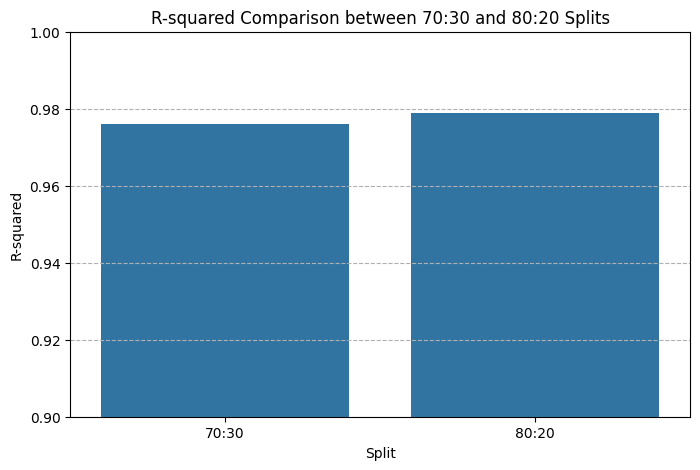


--- Visual Comparison of MAE ---


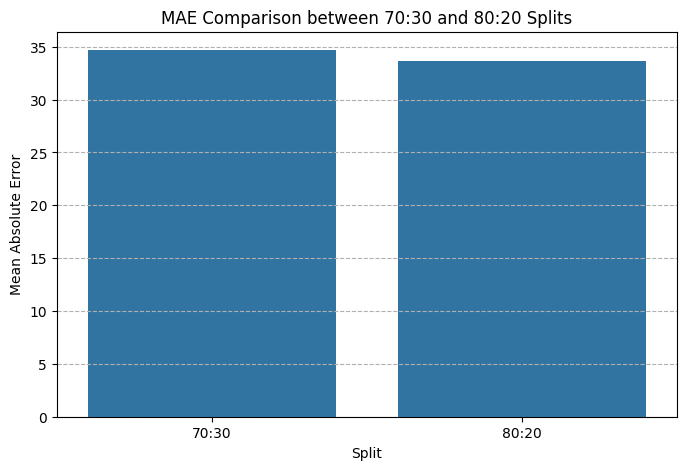

In [36]:
metrics_data = {
    'Split': ['70:30', '80:20'],
    'MAE': [mae_70, mae_80],
    'MSE': [mse_70, mse_80],
    'RMSE': [rmse_70, rmse_80],
    'R-squared': [r2_70, r2_80]
}

performance_df = pd.DataFrame(metrics_data)
print(performance_df.round(2))

print("\n--- Visual Comparison of R-squared ---")
plt.figure(figsize=(8, 5))
sns.barplot(x='Split', y='R-squared', data=performance_df)
plt.title('R-squared Comparison between 70:30 and 80:20 Splits')
plt.ylabel('R-squared')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()

print("\n--- Visual Comparison of MAE ---")
plt.figure(figsize=(8, 5))
sns.barplot(x='Split', y='MAE', data=performance_df)
plt.title('MAE Comparison between 70:30 and 80:20 Splits')
plt.ylabel('Mean Absolute Error')
plt.grid(axis='y', linestyle='--')
plt.show()

## Comprehensive Summary of Findings

## Train-Test Split (70:30)

In [16]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train (70:30 split): {X_train_70.shape}")
print(f"Shape of X_test (70:30 split): {X_test_70.shape}")
print(f"Shape of y_train (70:30 split): {y_train_70.shape}")
print(f"Shape of y_test (70:30 split): {y_test_70.shape}")

Shape of X_train (70:30 split): (5834, 632)
Shape of X_test (70:30 split): (2501, 632)
Shape of y_train (70:30 split): (5834,)
Shape of y_test (70:30 split): (2501,)


### Scaling numerical features for 70:30 split

In [17]:
scaler_70 = StandardScaler()
X_train_70[numerical_cols_to_scale] = scaler_70.fit_transform(X_train_70[numerical_cols_to_scale])
X_test_70[numerical_cols_to_scale] = scaler_70.transform(X_test_70[numerical_cols_to_scale])

print("Numerical columns scaled for 70:30 split successfully.")
print("X_train_70 head after scaling:")
display(X_train_70.head())
print("X_test_70 head after scaling:")
display(X_test_70.head())

Numerical columns scaled for 70:30 split successfully.
X_train_70 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
2351,-0.008589,0.020407,-0.097814,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5857,-0.292457,-0.301596,-0.233697,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
430,-0.173150,-0.162222,-0.205915,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4339,-0.169036,-0.195864,-0.041364,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
6946,-0.292457,-0.296790,-0.265991,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


X_test_70 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
1768,-0.255430,-0.263148,-0.237723,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5550,-0.263658,-0.267954,-0.242663,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7978,-0.292457,-0.296790,-0.265762,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
932,-0.267773,-0.267954,-0.263078,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5357,-0.243088,-0.248730,-0.183844,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Train Linear Regression Model (70:30 Split)

In [18]:
model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)

print("Linear Regression model trained successfully for 70:30 split.")

Linear Regression model trained successfully for 70:30 split.


### Make Predictions (70:30 Split)

In [19]:
y_pred_70 = model_70.predict(X_test_70)

print("Predictions made successfully for 70:30 split.")
print(f"First 5 predictions: {y_pred_70[:5]}")
print(f"First 5 actual values: {y_test_70[:5].values}")

Predictions made successfully for 70:30 split.
First 5 predictions: [ 8.87820299  9.09272453  3.32594236  3.01432131 20.57137888]
First 5 actual values: [21.2   24.728  2.    11.    32.36 ]


### Evaluate Model Performance (70:30 Split)

In [20]:
mae_70 = mean_absolute_error(y_test_70, y_pred_70)
mse_70 = mean_squared_error(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_70, y_pred_70)

print(f"--- Performance Metrics (70:30 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_70:.2f}")
print(f"Mean Squared Error (MSE): {mse_70:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_70:.2f}")
print(f"R-squared (R2): {r2_70:.2f}")

--- Performance Metrics (70:30 Split) ---
Mean Absolute Error (MAE): 34.68
Mean Squared Error (MSE): 5927.43
Root Mean Squared Error (RMSE): 76.99
R-squared (R2): 0.98


### Visualize Actual vs. Predicted (70:30 Split)

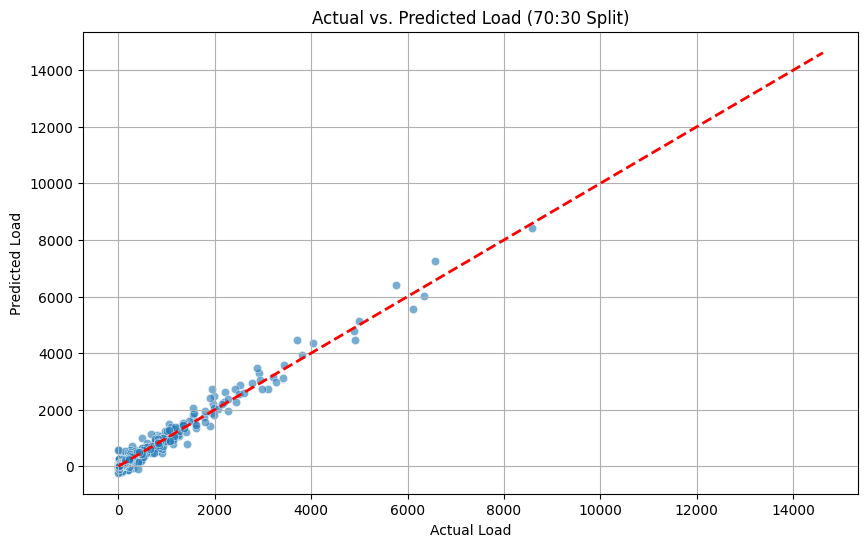

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_70, y=y_pred_70, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (70:30 Split)')
plt.grid(True)
plt.show()

### Evaluate Model Performance (80:20 Split)

In [14]:
mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

print(f"--- Performance Metrics (80:20 Split) ---")
print(f"Mean Absolute Error (MAE): {mae_80:.2f}")
print(f"Mean Squared Error (MSE): {mse_80:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_80:.2f}")
print(f"R-squared (R2): {r2_80:.2f}")

--- Performance Metrics (80:20 Split) ---
Mean Absolute Error (MAE): 33.61
Mean Squared Error (MSE): 5764.84
Root Mean Squared Error (RMSE): 75.93
R-squared (R2): 0.98


### Visualize Actual vs. Predicted (80:20 Split)

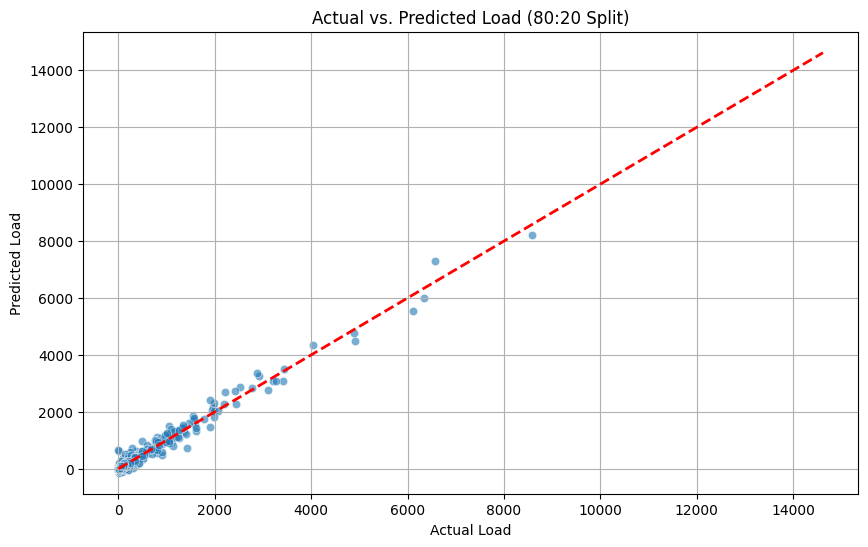

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_80, y=y_pred_80, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs. Predicted Load (80:20 Split)')
plt.grid(True)
plt.show()

### Train Linear Regression Model (80:20 Split)

In [12]:
model_80 = LinearRegression()
model_80.fit(X_train_80, y_train_80)

print("Linear Regression model trained successfully for 80:20 split.")

Linear Regression model trained successfully for 80:20 split.


### Make Predictions (80:20 Split)

In [13]:
y_pred_80 = model_80.predict(X_test_80)

print("Predictions made successfully for 80:20 split.")
print(f"First 5 predictions: {y_pred_80[:5]}")
print(f"First 5 actual values: {y_test_80[:5].values}")

Predictions made successfully for 80:20 split.
First 5 predictions: [ 9.40193298  9.17700358  3.39707138 -0.50349813 23.92708459]
First 5 actual values: [21.2   24.728  2.    11.    32.36 ]


## Train-Test Split (80:20)

In [10]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train (80:20 split): {X_train_80.shape}")
print(f"Shape of X_test (80:20 split): {X_test_80.shape}")
print(f"Shape of y_train (80:20 split): {y_train_80.shape}")
print(f"Shape of y_test (80:20 split): {y_test_80.shape}")

Shape of X_train (80:20 split): (6668, 632)
Shape of X_test (80:20 split): (1667, 632)
Shape of y_train (80:20 split): (6668,)
Shape of y_test (80:20 split): (1667,)


### Scaling numerical features for 80:20 split

In [11]:
scaler_80 = StandardScaler()
X_train_80[numerical_cols_to_scale] = scaler_80.fit_transform(X_train_80[numerical_cols_to_scale])
X_test_80[numerical_cols_to_scale] = scaler_80.transform(X_test_80[numerical_cols_to_scale])

print("Numerical columns scaled for 80:20 split successfully.")
print("X_train_80 head after scaling:")
display(X_train_80.head())
print("X_test_80 head after scaling:")
display(X_test_80.head())

Numerical columns scaled for 80:20 split successfully.
X_train_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
2233,5.161918,5.456363,3.815199,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6798,-0.172597,-0.166034,-0.172618,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3964,-0.006955,-0.002707,-0.008894,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1321,-0.159855,-0.141287,-0.201538,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8140,-0.295766,-0.304614,-0.260752,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


X_test_80 head after scaling:


,TotServices,BilledServices,Units,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,Circle_HANUMAKONDA,Circle_JAGITYAL,Circle_JANGAON,Circle_KAMAREDDY,...,Section_YEDPALLY,Section_YEDULAPURAM,Section_YELLAMPET,Section_YELLANDU TOWN,Section_YELLAREDDIPALLY,Section_YELLAREDDY,Section_YERGATLA,Section_YERRUPALEM,Section_YLD RURAL,Section_ZAFARGADH
1768,-0.257541,-0.265019,-0.239171,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5550,-0.266036,-0.269969,-0.244230,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
7978,-0.295766,-0.299665,-0.267887,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
932,-0.270283,-0.269969,-0.265138,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5357,-0.244800,-0.250172,-0.183993,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
